In [5]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

base = Path().resolve().parent
csv_file = base / "diabetes.csv"

df = pd.read_csv(csv_file)
df.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


In [6]:
df.shape

(768, 9)

In [7]:
df.describe()


,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
count,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000
mean,3.845052,120.894531,69.105469,20.536458,79.799479,31.992578,0.471876,33.240885,0.348958
std,3.369578,31.972618,19.355807,15.952218,115.244002,7.884160,0.331329,11.760232,0.476951
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.078000,21.000000,0.000000
25%,1.000000,99.000000,62.000000,0.000000,0.000000,27.300000,0.243750,24.000000,0.000000
50%,3.000000,117.000000,72.000000,23.000000,30.500000,32.000000,0.372500,29.000000,0.000000
75%,6.000000,140.250000,80.000000,32.000000,127.250000,36.600000,0.626250,41.000000,1.000000
max,17.000000,199.000000,122.000000,99.000000,846.000000,67.100000,2.420000,81.000000,1.000000


## Missing Values already imputed as 0
Some values missing values were wrongly imputed with zeroes. They should be replaced with a recognizeable label(NaN)

In [7]:
df.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


In [27]:
df_1 = df.copy()
cols = df_1.columns.drop(["Pregnancies", "Outcome"])
df_1[cols] = df_1[cols].replace(0, np.nan)

df_1
df_1.describe()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
count,768.000000,763.000000,733.000000,541.000000,394.000000,757.000000,768.000000,768.000000,768.000000
mean,3.845052,121.686763,72.405184,29.153420,155.548223,32.457464,0.471876,33.240885,0.348958
std,3.369578,30.535641,12.382158,10.476982,118.775855,6.924988,0.331329,11.760232,0.476951
min,0.000000,44.000000,24.000000,7.000000,14.000000,18.200000,0.078000,21.000000,0.000000
25%,1.000000,99.000000,64.000000,22.000000,76.250000,27.500000,0.243750,24.000000,0.000000
50%,3.000000,117.000000,72.000000,29.000000,125.000000,32.300000,0.372500,29.000000,0.000000
75%,6.000000,141.000000,80.000000,36.000000,190.000000,36.600000,0.626250,41.000000,1.000000
max,17.000000,199.000000,122.000000,99.000000,846.000000,67.100000,2.420000,81.000000,1.000000


In [28]:
features_nan = [feature for feature in cols if df_1[feature].isnull().sum()>0] 
features_nan

['Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI']

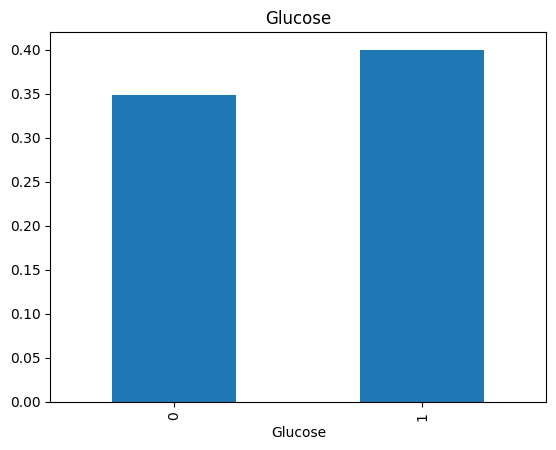

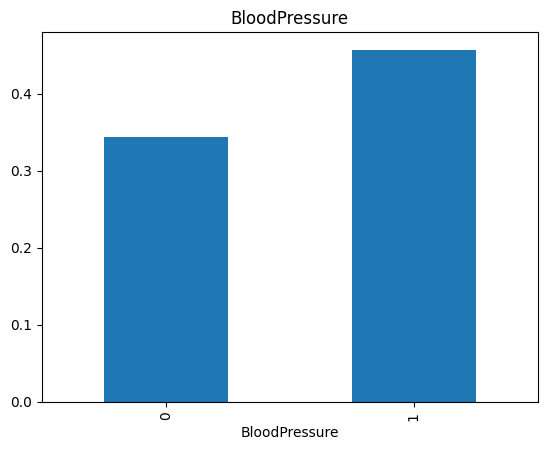

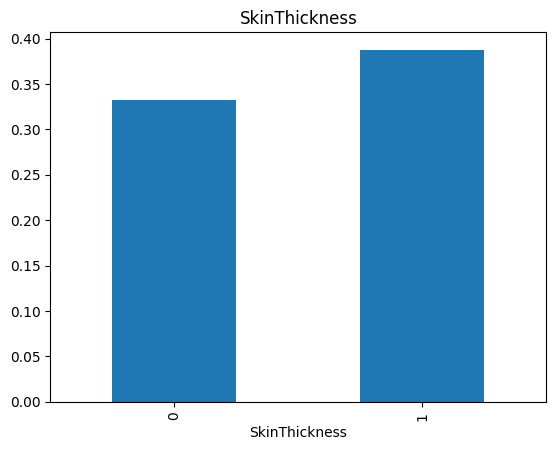

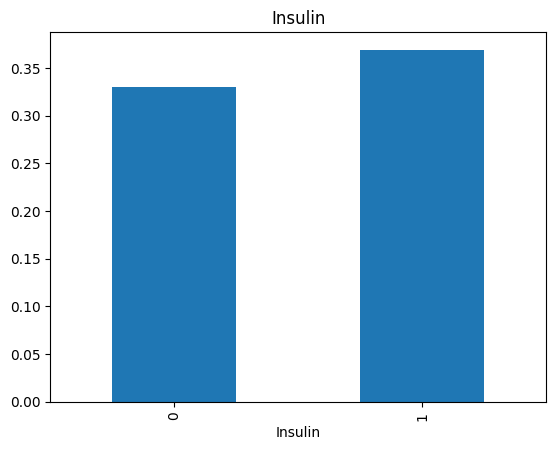

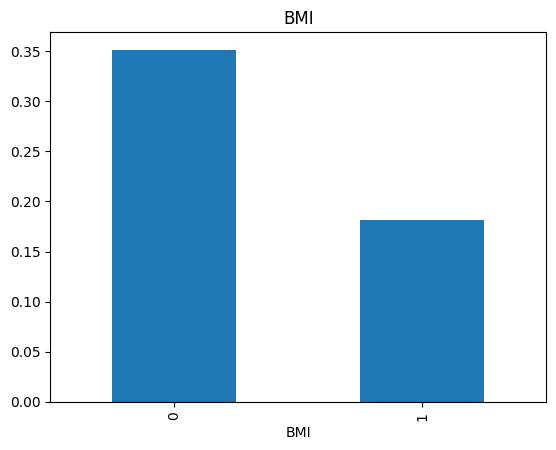

In [29]:
for feature in features_nan:
    data = df_1.copy()
    data[feature] = np.where(data[feature].isnull(), 1, 0)
    #Let's calculate the median Sale's price where the information is missing or provided
    data.groupby(feature)["Outcome"].mean().plot.bar()
    plt.title(feature)
    plt.show()
    

In [31]:
for feature in features_nan:
    df_1[feature+"_nan"] = np.where(df_1[feature].isnull(), 1, 0)
df_1.head()


,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome,Glucose_nan,BloodPressure_nan,SkinThickness_nan,Insulin_nan,BMI_nan
0,6,148.0,72.0,35.0,NaN,33.6,0.627,50,1,0,0,0,1,0
1,1,85.0,66.0,29.0,NaN,26.6,0.351,31,0,0,0,0,1,0
2,8,183.0,64.0,NaN,NaN,23.3,0.672,32,1,0,0,1,1,0
3,1,89.0,66.0,23.0,94.0,28.1,0.167,21,0,0,0,0,0,0
4,0,137.0,40.0,35.0,168.0,43.1,2.288,33,1,0,0,0,0,0


In [32]:
for feature in features_nan:
    median_0 = df_1[df_1["Outcome"] == 0][feature].median()
    median_1 = df_1[df_1["Outcome"] == 1][feature].median()

    df_1.loc[(df_1[feature].isnull()) & (df_1["Outcome"] == 0), feature] = median_0
    df_1.loc[(df_1[feature].isnull()) & (df_1["Outcome"] == 1), feature] = median_1
    



In [33]:
df_1.isnull().sum()


Pregnancies                 0
Glucose                     0
BloodPressure               0
SkinThickness               0
Insulin                     0
BMI                         0
DiabetesPedigreeFunction    0
Age                         0
Outcome                     0
Glucose_nan                 0
BloodPressure_nan           0
SkinThickness_nan           0
Insulin_nan                 0
BMI_nan                     0
dtype: int64

## Numerical columns analysis
Check for outliers,skewness, rare categorical variables etc

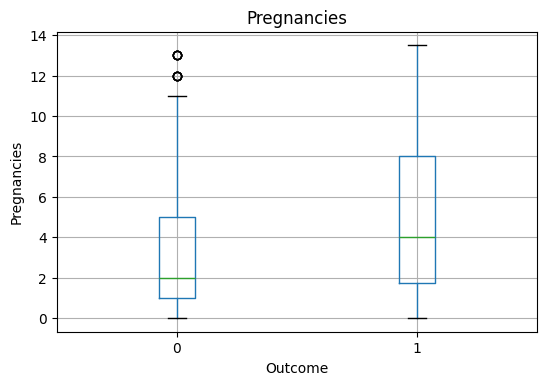

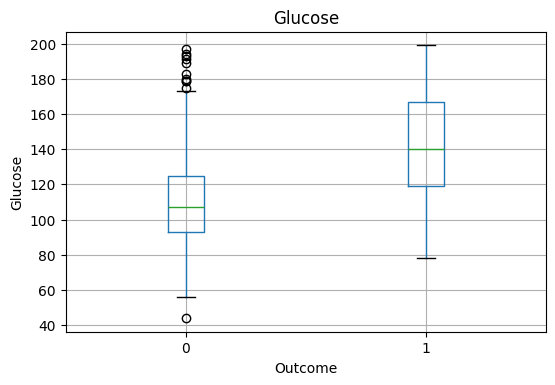

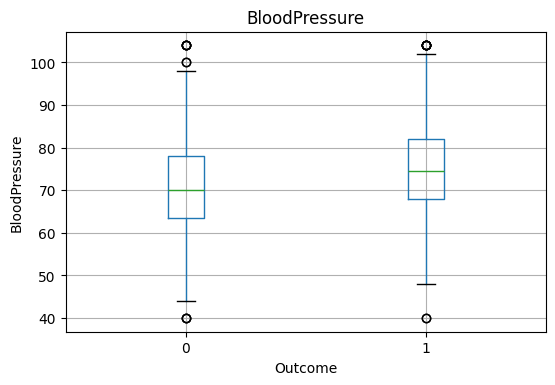

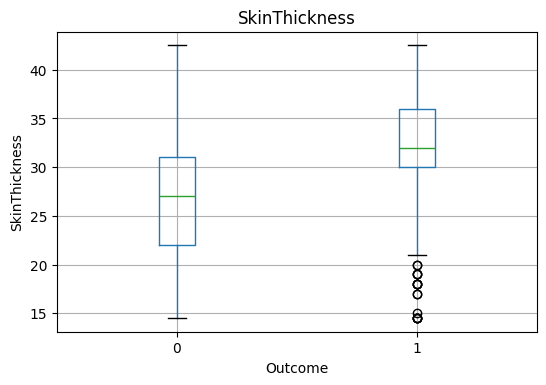

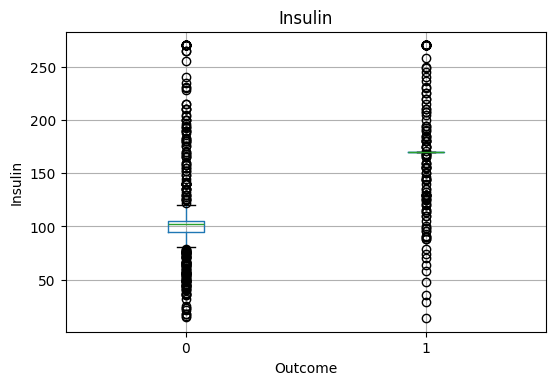

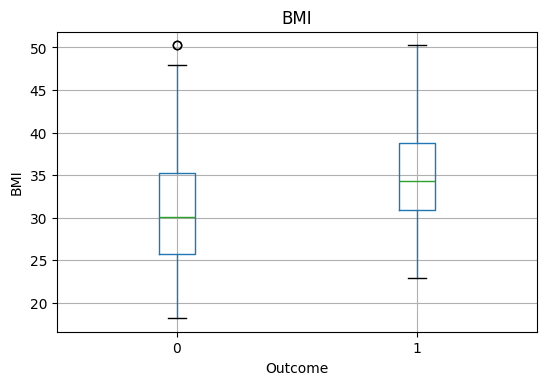

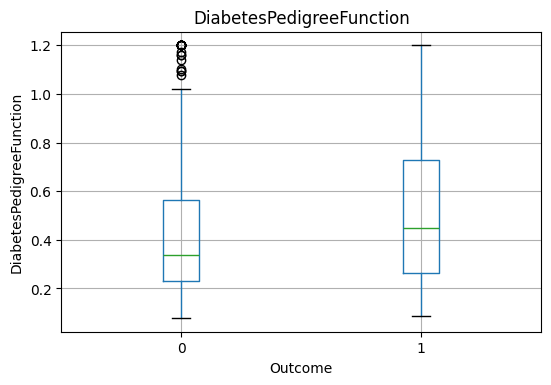

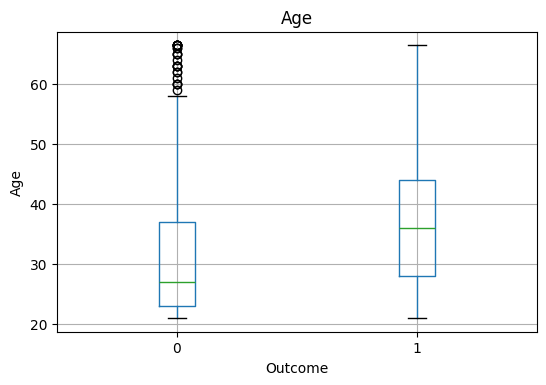

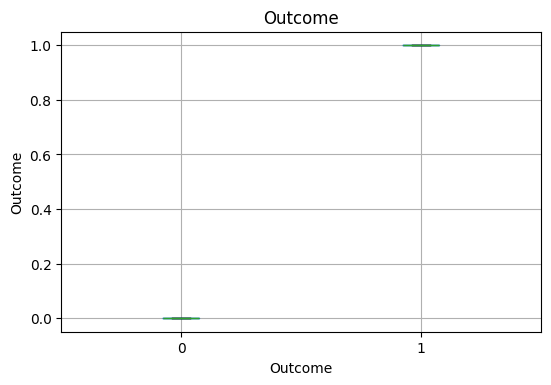

In [40]:
def detect_outlier():
    for feature in df.columns:
        df_1.boxplot(column=feature, by="Outcome", figsize=(6,4))
        plt.title(feature)
        plt.suptitle("")
        plt.xlabel("Outcome")
        plt.ylabel(feature)
        plt.show()
                    
detect_outlier()

## Outliers detected in original dataset

In [41]:
for feature in df.columns.drop("Outcome"):
    Q1 = df_1[feature].quantile(0.25)
    Q3 = df_1[feature].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 3 * IQR
    upper = Q3 + 3 * IQR
    df_1[feature] = df_1[feature].clip(lower, upper)
    
    


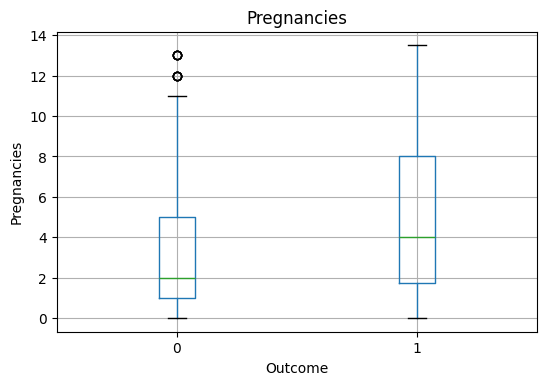

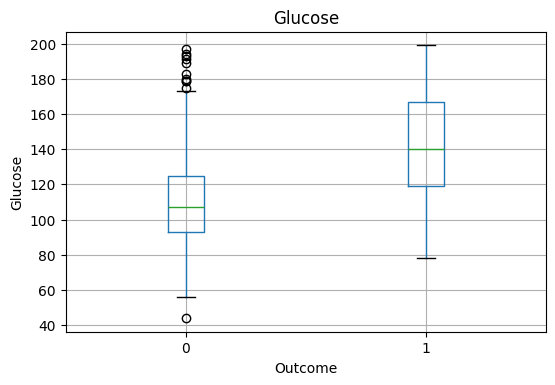

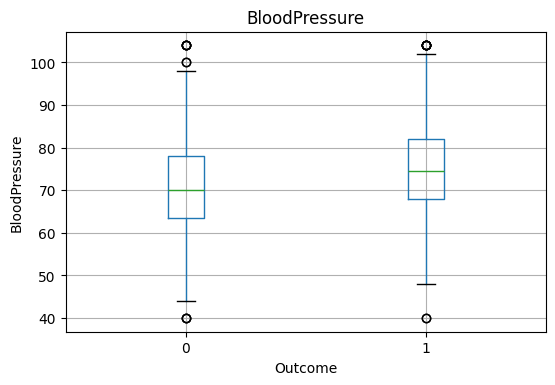

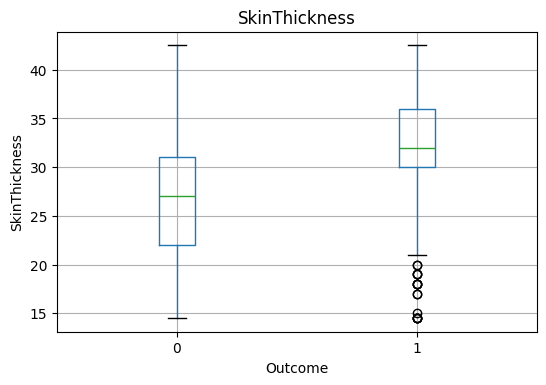

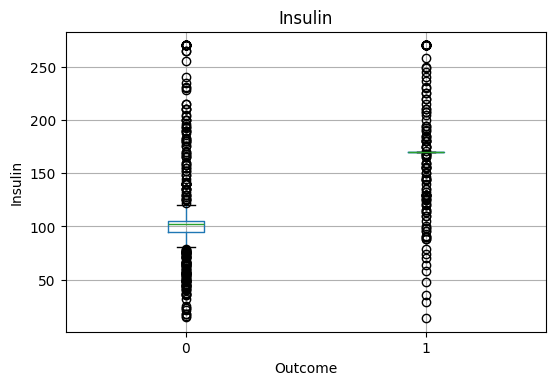

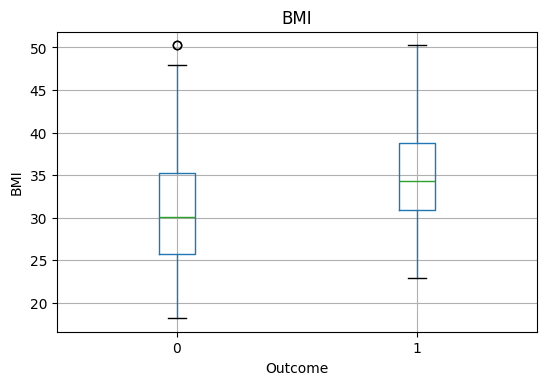

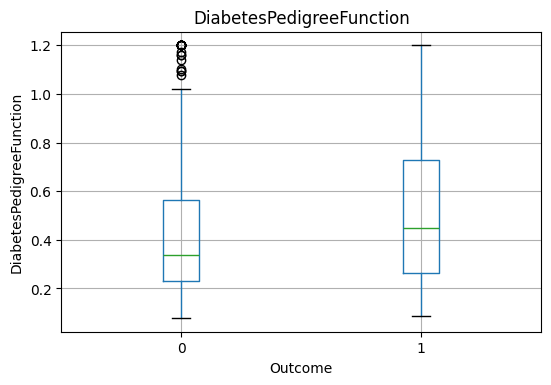

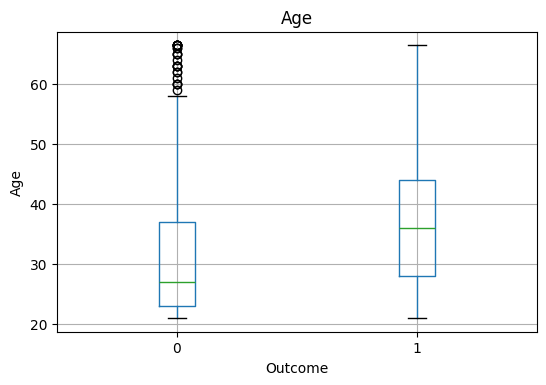

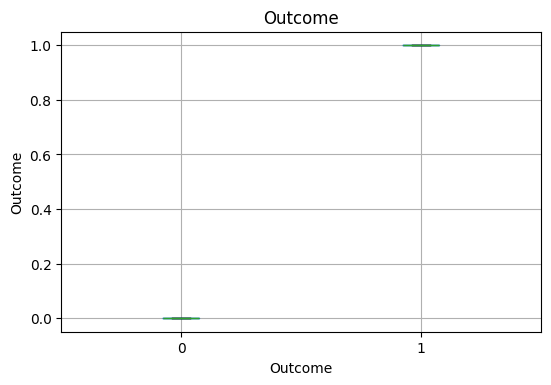

In [42]:
detect_outlier()



In [43]:
df_1.skew()

Pregnancies                 0.853962
Glucose                     0.532324
BloodPressure               0.104659
SkinThickness              -0.042302
Insulin                     0.731424
BMI                         0.357907
DiabetesPedigreeFunction    1.024428
Age                         1.067170
Outcome                     0.635017
Glucose_nan                 0.000000
BloodPressure_nan           0.000000
SkinThickness_nan           0.897775
Insulin_nan                 0.052203
BMI_nan                     0.000000
dtype: float64

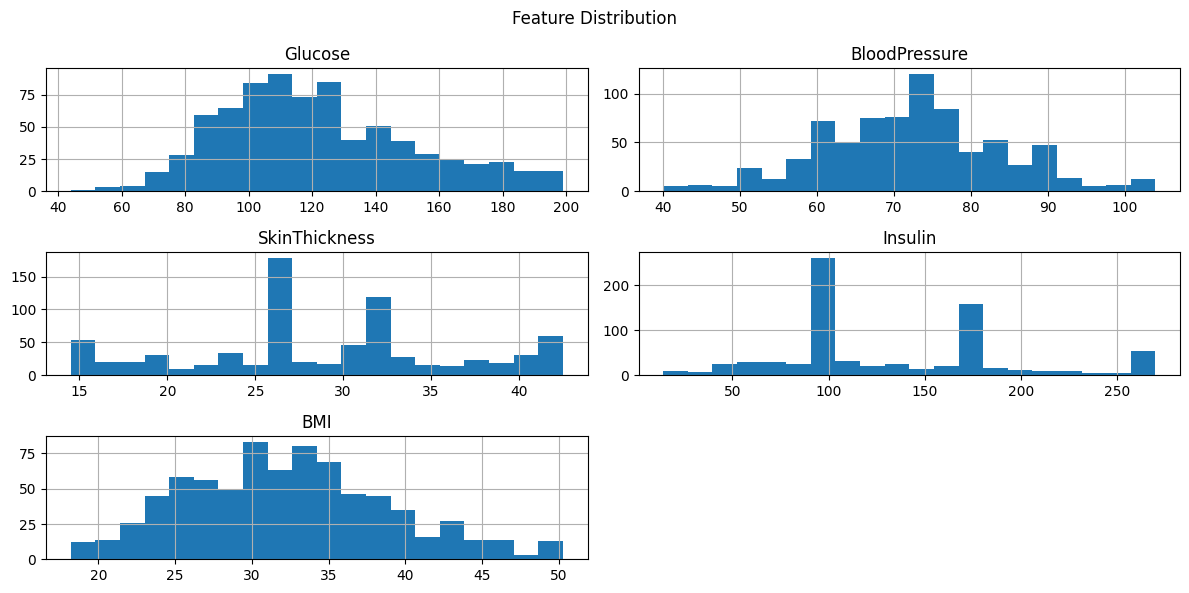

In [45]:
def viz_distributions():
    df_1[features_nan].hist(figsize=(12,6), bins=20)
    plt.suptitle("Feature Distribution")
    plt.tight_layout()
    plt.show()

viz_distributions()

## handle skewness with log transformation

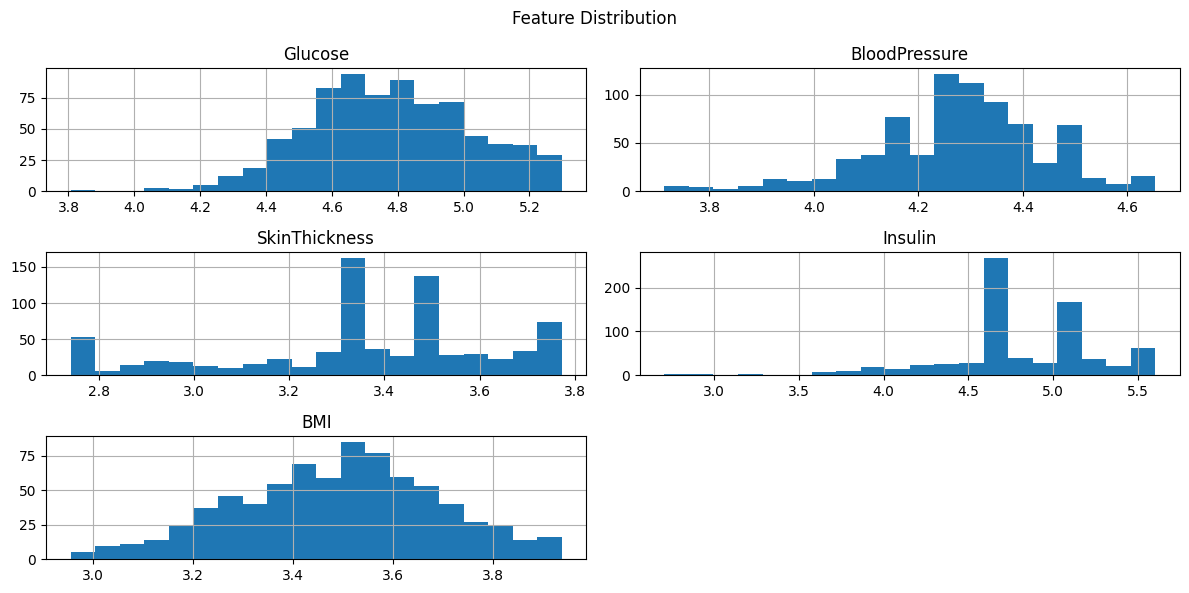

In [46]:
for feature in df.columns.drop("Outcome"):
    df_1[feature] = np.log1p(df_1[feature])

viz_distributions()

In [47]:
df_1.skew()

Pregnancies                -0.249275
Glucose                    -0.058987
BloodPressure              -0.451987
SkinThickness              -0.648738
Insulin                    -0.777685
BMI                        -0.130016
DiabetesPedigreeFunction    0.703791
Age                         0.593359
Outcome                     0.635017
Glucose_nan                 0.000000
BloodPressure_nan           0.000000
SkinThickness_nan           0.897775
Insulin_nan                 0.052203
BMI_nan                     0.000000
dtype: float64

In [48]:
df_1.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome,Glucose_nan,BloodPressure_nan,SkinThickness_nan,Insulin_nan,BMI_nan
0,1.945910,5.003946,4.290459,3.583519,5.138735,3.543854,0.486738,3.931826,1,0,0,0,1,0
1,0.693147,4.454347,4.204693,3.401197,4.639572,3.317816,0.300845,3.465736,0,0,0,0,1,0
2,2.197225,5.214936,4.174387,3.496508,5.138735,3.190476,0.514021,3.496508,1,0,0,1,1,0
3,0.693147,4.499810,4.204693,3.178054,4.553877,3.370738,0.154436,3.091042,0,0,0,0,0,0
4,0.000000,4.927254,3.713572,3.583519,5.129899,3.786460,0.788457,3.526361,1,0,0,0,0,0


In [49]:
df_1.isnull().sum()

Pregnancies                 0
Glucose                     0
BloodPressure               0
SkinThickness               0
Insulin                     0
BMI                         0
DiabetesPedigreeFunction    0
Age                         0
Outcome                     0
Glucose_nan                 0
BloodPressure_nan           0
SkinThickness_nan           0
Insulin_nan                 0
BMI_nan                     0
dtype: int64

In [51]:
save_path = base.parent / "diabetes_clean.csv"
df_1.to_csv(save_path, index=False)
print(f"Saved to {save_path}")

Saved to C:\Users\USER\Desktop\diabetes_clean.csv
